In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/processed/model_data.csv")

wb_cols = ["inflation", "youth_unemployment", "income_inequality", "income_level_code"]
exist = [c for c in wb_cols if c in df.columns]

print("="*70)
print("WORLD BANK LAYER — BASIC CHECK")
print("="*70)
print("Dataset shape:", df.shape)
print("WB columns found:", exist)
print("Date range:", df["month_year"].min(), "→", df["month_year"].max())
print("Unique countries:", df["country_code"].nunique())

print("\nMissingness (%):")
print((df[exist].isna().mean()*100).sort_values(ascending=False))

print("\nQuick summary (non-null only):")
print(df[exist].describe().T[["count","mean","std","min","max"]])



WORLD BANK LAYER — BASIC CHECK
Dataset shape: (278820, 60)
WB columns found: ['inflation', 'youth_unemployment', 'income_inequality', 'income_level_code']
Date range: 2018-01-01 → 2025-06-01
Unique countries: 220

Missingness (%):
income_inequality     66.115774
youth_unemployment    55.713363
inflation             32.111039
income_level_code     30.837099
dtype: float64

Quick summary (non-null only):
                       count       mean        std        min         max
inflation           189288.0   7.991595  22.847717  -4.644709  557.201817
youth_unemployment  123480.0  17.617915   8.494006   2.970000   53.764000
income_inequality    94476.0  36.342296   6.957893  23.200000   55.100000
income_level_code   192840.0   0.602489   1.385876  -2.000000    2.000000


In [5]:
print("="*70)
print("WITHIN-YEAR VARIATION CHECK")
print("="*70)

df["year"] = pd.to_datetime(df["month_year"]).dt.year

for col in wb_cols:
    if col in df.columns:
        var_check = (
            df.groupby(["country_code", "year"])[col]
            .nunique()
            .dropna()
        )
        pct_constant = (var_check == 1).mean() * 100
        print(f"\n{col}:")
        print(f"  % country-years constant within year: {pct_constant:.2f}%")
        print(f"  Avg unique values per country-year: {var_check.mean():.2f}")

WITHIN-YEAR VARIATION CHECK

inflation:
  % country-years constant within year: 54.83%
  Avg unique values per country-year: 0.55

youth_unemployment:
  % country-years constant within year: 32.73%
  Avg unique values per country-year: 0.33

income_inequality:
  % country-years constant within year: 21.65%
  Avg unique values per country-year: 0.22

income_level_code:
  % country-years constant within year: 55.68%
  Avg unique values per country-year: 0.56


In [6]:
print("="*70)
print("CLEAN WITHIN-YEAR VARIATION CHECK")
print("="*70)

for col in wb_cols:
    if col in df.columns:
        tmp = df.dropna(subset=[col])
        var_check = tmp.groupby(["country_code","year"])[col].nunique()
        pct_constant = (var_check == 1).mean() * 100
        print(f"\n{col}:")
        print(f"  % constant within year (non-missing only): {pct_constant:.2f}%")
        print(f"  Avg unique values per country-year: {var_check.mean():.2f}")

CLEAN WITHIN-YEAR VARIATION CHECK

inflation:
  % constant within year (non-missing only): 100.00%
  Avg unique values per country-year: 1.00

youth_unemployment:
  % constant within year (non-missing only): 100.00%
  Avg unique values per country-year: 1.00

income_inequality:
  % constant within year (non-missing only): 100.00%
  Avg unique values per country-year: 1.00

income_level_code:
  % constant within year (non-missing only): 100.00%
  Avg unique values per country-year: 1.00


In [7]:
print("="*70)
print("CROSS-COUNTRY VARIANCE PER YEAR")
print("="*70)

for col in wb_cols:
    if col in df.columns:
        tmp = df.dropna(subset=[col])
        yearly_std = tmp.groupby("year")[col].std()
        print(f"\n{col}:")
        print("Mean yearly std:", round(yearly_std.mean(), 2))
        print("Min yearly std:", round(yearly_std.min(), 2))
        print("Max yearly std:", round(yearly_std.max(), 2))

CROSS-COUNTRY VARIANCE PER YEAR

inflation:
Mean yearly std: 20.29
Min yearly std: 6.36
Max yearly std: 36.59

youth_unemployment:
Mean yearly std: 8.36
Min yearly std: 6.82
Max yearly std: 9.66

income_inequality:
Mean yearly std: 6.84
Min yearly std: 6.53
Max yearly std: 7.43

income_level_code:
Mean yearly std: 1.39
Min yearly std: 1.37
Max yearly std: 1.4


**All World Bank indicators show meaningful cross-country variance.**

- Indicators are annual and structurally stable within year.
- They represent regime-level vulnerability rather than short-term triggers.

Implication:
World Bank layer functions as a structural conditioning layer in the forecasting system.

In [8]:
print("="*70)
print("COUNTRY-YEAR MACRO vs CONFLICT CORRELATION")
print("="*70)

# Aggregate to country-year
agg = (
    df.groupby(["country_code","year"])
    .agg({
        "Battles":"sum",
        "Explosions/Remote violence":"sum",
        "Violence against civilians":"sum",
        "inflation":"mean",
        "youth_unemployment":"mean",
        "income_inequality":"mean",
        "income_level_code":"mean"
    })
    .reset_index()
)

# Drop rows with missing macro
agg = agg.dropna(subset=wb_cols)

targets = ["Battles","Explosions/Remote violence","Violence against civilians"]

for macro in wb_cols:
    print(f"\n=== {macro} ===")
    for target in targets:
        corr = agg[macro].corr(agg[target])
        print(f"{target}: {round(corr,3)}")

COUNTRY-YEAR MACRO vs CONFLICT CORRELATION

=== inflation ===
Battles: 0.003
Explosions/Remote violence: 0.041
Violence against civilians: 0.011

=== youth_unemployment ===
Battles: 0.228
Explosions/Remote violence: 0.329
Violence against civilians: 0.206

=== income_inequality ===
Battles: 0.399
Explosions/Remote violence: 0.336
Violence against civilians: 0.429

=== income_level_code ===
Battles: -0.089
Explosions/Remote violence: -0.184
Violence against civilians: -0.113


**Interpretation : Macro vs Conflict (Country-Year Level)**

- Inflation shows near-zero linear correlation with annual conflict totals.
- Youth unemployment displays moderate positive correlation (0.20–0.33).
- Income inequality shows the strongest structural association (0.33–0.43).
- Higher income-level categories correlate weakly with lower conflict.

Implication:
The World Bank layer functions primarily as a structural vulnerability signal.
Income inequality appears to be the most relevant macro feature in this dataset.

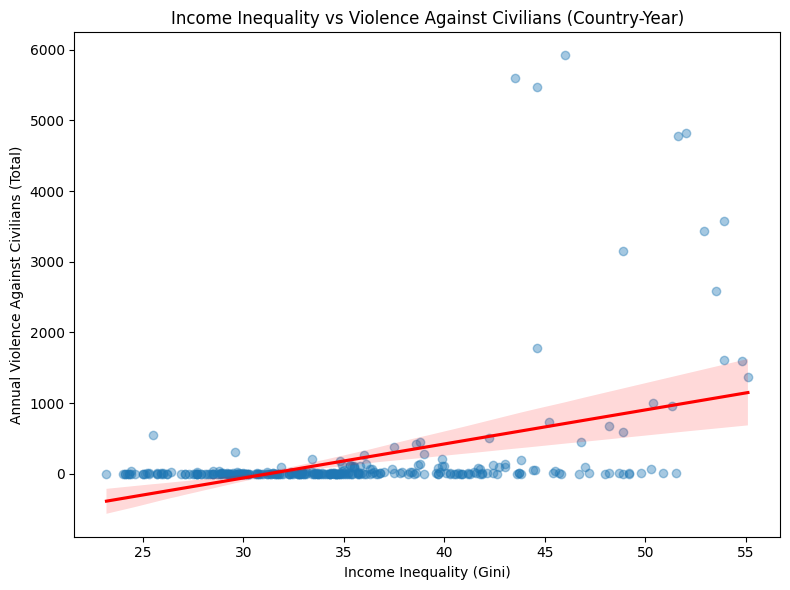

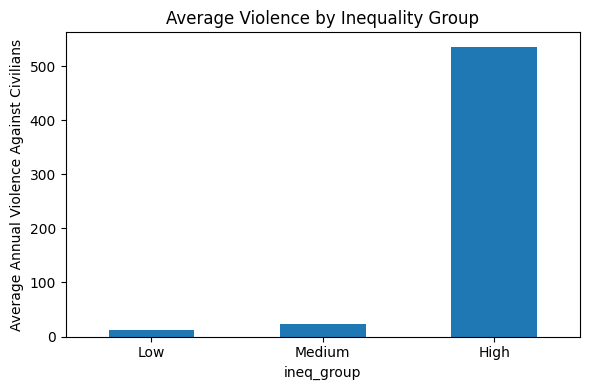

ineq_group
Low        12.480392
Medium     23.640000
High      535.460784
Name: Violence against civilians, dtype: float64


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.regplot(
    data=agg,
    x="income_inequality",
    y="Violence against civilians",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

plt.title("Income Inequality vs Violence Against Civilians (Country-Year)")
plt.xlabel("Income Inequality (Gini)")
plt.ylabel("Annual Violence Against Civilians (Total)")
plt.tight_layout()
plt.show()

# Create inequality tertiles
agg["ineq_group"] = pd.qcut(agg["income_inequality"], q=3, labels=["Low","Medium","High"])

group_means = agg.groupby("ineq_group", observed=False)["Violence against civilians"].mean()

plt.figure(figsize=(6,4))
group_means.plot(kind="bar")
plt.title("Average Violence by Inequality Group")
plt.ylabel("Average Annual Violence Against Civilians")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(group_means)

**Insight : Income Inequality**

Income inequality shows a strong structural association with violence against civilians at the country-year level.

While low and medium inequality countries exhibit very low average violence levels (≈12–23 events annually), high inequality countries exhibit dramatically higher averages (≈535).

The scatter plot reveals that extreme violence levels occur almost exclusively within the highest inequality range.

This suggests that inequality may function as a structural enabling condition rather than a linear driver of conflict.

***The relationship appears nonlinear and threshold-like.***

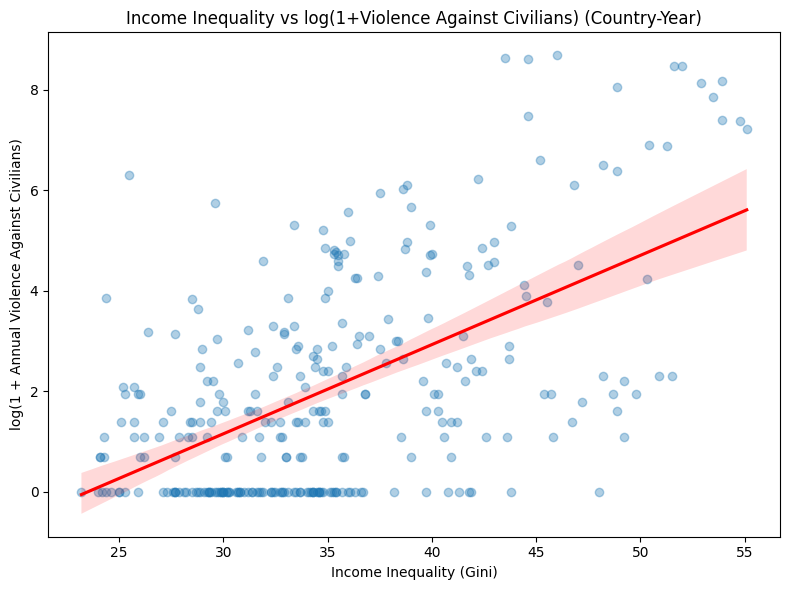

In [12]:
plt.figure(figsize=(8,6))
sns.regplot(
    data=agg,
    x="income_inequality",
    y=np.log1p(agg["Violence against civilians"]),
    scatter_kws={"alpha":0.35},
    line_kws={"color":"red"}
)
plt.title("Income Inequality vs log(1+Violence Against Civilians) (Country-Year)")
plt.xlabel("Income Inequality (Gini)")
plt.ylabel("log(1 + Annual Violence Against Civilians)")
plt.tight_layout()
plt.show()

                  mean  median     iqr  count
ineq_group                                   
Low          12.480392     1.0    4.00    102
Medium       23.640000     3.0   16.00    100
High        535.460784    18.5  179.25    102


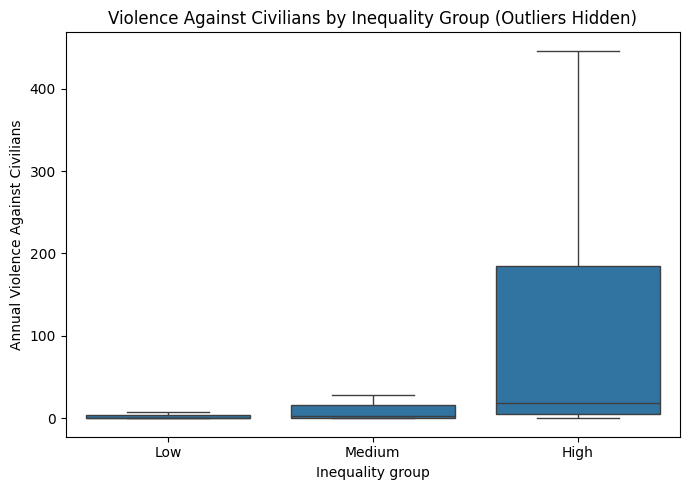

In [16]:
def iqr(s):
    return s.quantile(0.75) - s.quantile(0.25)

summary = (
    agg.groupby("ineq_group", observed=False)["Violence against civilians"]
    .agg(mean="mean", median="median", iqr=iqr, count="count")
)

print(summary)

# visual: boxplot (robust)
plt.figure(figsize=(7,5))
sns.boxplot(data=agg, x="ineq_group", y="Violence against civilians", showfliers=False)
plt.title("Violence Against Civilians by Inequality Group (Outliers Hidden)")
plt.xlabel("Inequality group")
plt.ylabel("Annual Violence Against Civilians")
plt.tight_layout()
plt.show()

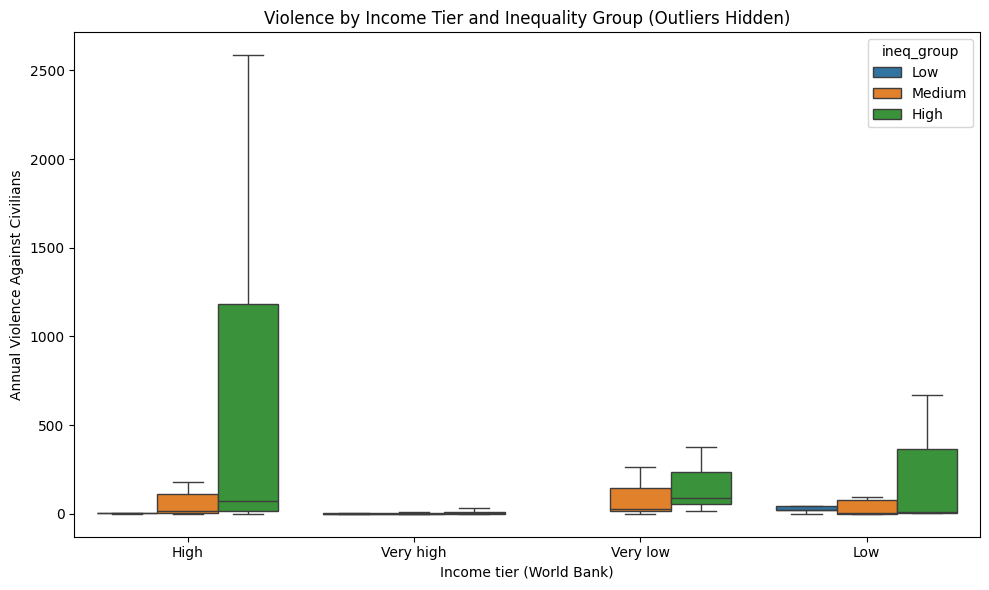

In [14]:
# income level buckets (your encoding: -2 very low, -1 low, 1 high, 2 very high)
agg2 = agg.dropna(subset=["income_level_code"]).copy()
agg2["income_tier"] = agg2["income_level_code"].map({-2:"Very low", -1:"Low", 1:"High", 2:"Very high"})

plt.figure(figsize=(10,6))
sns.boxplot(
    data=agg2,
    x="income_tier",
    y="Violence against civilians",
    hue="ineq_group",
    showfliers=False
)
plt.title("Violence by Income Tier and Inequality Group (Outliers Hidden)")
plt.xlabel("Income tier (World Bank)")
plt.ylabel("Annual Violence Against Civilians")
plt.tight_layout()
plt.show()

**Findings : Income Inequality and Violence**

Income inequality demonstrates a consistent structural association with violence against civilians at the country-year level.

The positive relationship remains visible after log transformation, indicating that the result is not driven solely by extreme war outliers.

Boxplots (with outliers removed) show clear distributional separation between low, medium, and high inequality groups, with high inequality countries exhibiting substantially higher median and dispersion of violence.

Importantly, this separation persists within World Bank income tiers, suggesting that inequality is not merely a proxy for economic development level.

These findings support the interpretation of inequality as a structural enabling condition for high-intensity conflict rather than a short-term trigger.

***Now working on Inflation as most likely it should be a non-linear dynamic variable instead of linear correlate***

Average violence:
inflation_shock
0    159.806584
1    318.377049
Name: Violence against civilians, dtype: float64


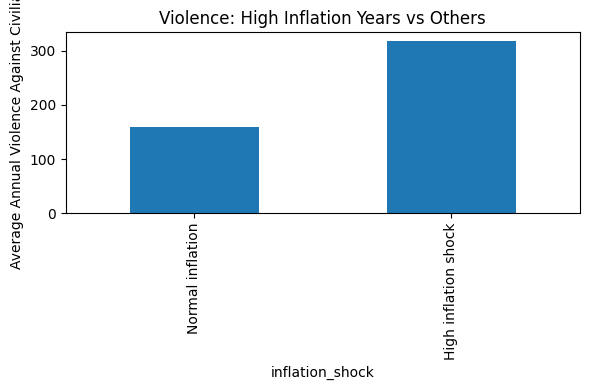

In [17]:
# Create inflation shock group (country-year level)
agg["inflation_group"] = pd.qcut(agg["inflation"], q=5, labels=False)

# Top quintile = high inflation shock
agg["inflation_shock"] = (agg["inflation_group"] == 4).astype(int)

# Compare violence
shock_means = agg.groupby("inflation_shock", observed=False)["Violence against civilians"].mean()

print("Average violence:")
print(shock_means)

# Visual
plt.figure(figsize=(6,4))
shock_means.plot(kind="bar")
plt.title("Violence: High Inflation Years vs Others")
plt.xticks([0,1], ["Normal inflation","High inflation shock"])
plt.ylabel("Average Annual Violence Against Civilians")
plt.tight_layout()
plt.show()

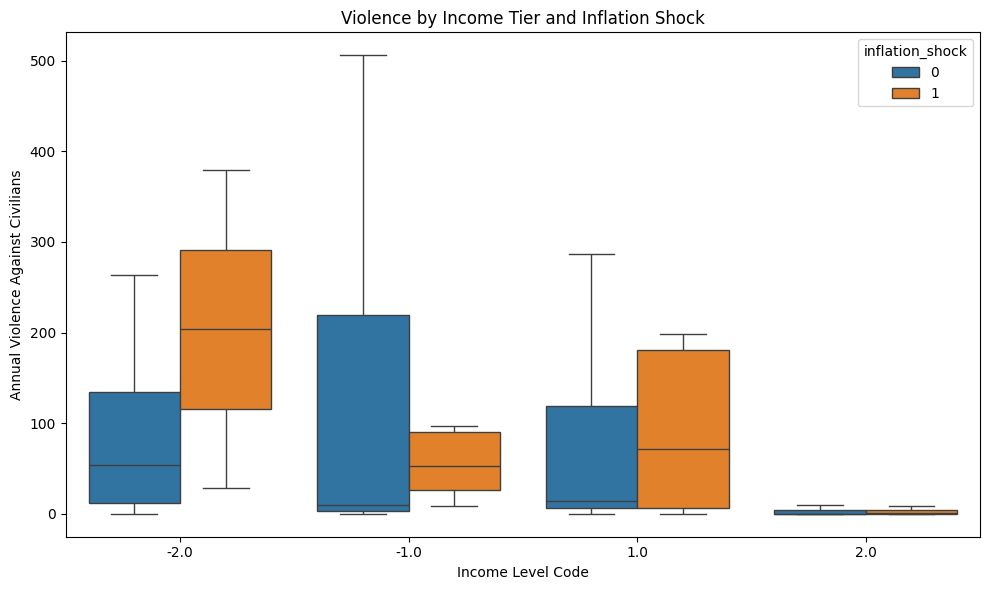

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=agg,
    x="income_level_code",
    y="Violence against civilians",
    hue="inflation_shock",
    showfliers=False
)

plt.title("Violence by Income Tier and Inflation Shock")
plt.xlabel("Income Level Code")
plt.ylabel("Annual Violence Against Civilians")
plt.tight_layout()
plt.show()

**Findings: Inflation Shock and Violence**

Inflation does not exhibit a strong linear relationship with conflict when treated as a continuous variable. However, when modeled as a shock condition (top quintile inflation years), a clear pattern emerges.

High inflation years are associated with substantially higher violence against civilians.

This effect is strongly conditional on income level. The inflation shock effect is most pronounced in very low and low income countries, weaker in high income countries, and nearly absent in very high income countries.

This suggests that **inflation** functions as a **dynamic accelerator of violence primarily in economically vulnerable contexts** rather than as a universal structural driver.

In [19]:
agg = agg.sort_values(["country_code", "year"])
agg["inflation_lag1"] = agg.groupby("country_code")["inflation"].shift(1)
print(agg[["country_code", "year", "inflation", "inflation_lag1"]].head(10))

corr_lag = agg[["inflation_lag1", "Violence against civilians"]].corr().iloc[0,1]
print("Lagged inflation correlation with violence:", round(corr_lag, 3))

   country_code  year  inflation  inflation_lag1
24          ALB  2018   2.028060             NaN
25          ALB  2019   1.411091        2.028060
26          ALB  2020   1.620887        1.411091
56          ARM  2018   2.520234             NaN
57          ARM  2019   1.443447        2.520234
58          ARM  2020   1.211436        1.443447
59          ARM  2021   7.184836        1.211436
88          AUS  2018   1.911401             NaN
96          AUT  2018   1.998380             NaN
97          AUT  2019   1.530896        1.998380
Lagged inflation correlation with violence: 0.106


Average violence by lagged inflation shock:
inflation_lag_shock
0    149.976923
1    437.727273
Name: Violence against civilians, dtype: float64


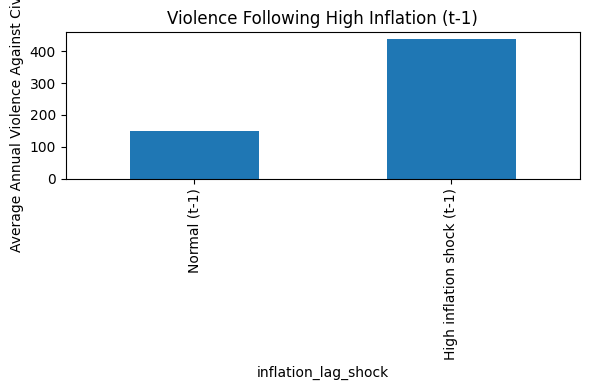

In [20]:
agg["inflation_lag_group"] = pd.qcut(
    agg["inflation_lag1"],
    q=5,
    labels=False,
    duplicates="drop"
)

agg["inflation_lag_shock"] = (agg["inflation_lag_group"] == 4).astype(int)

lag_means = agg.groupby("inflation_lag_shock", observed=False)["Violence against civilians"].mean()

print("Average violence by lagged inflation shock:")
print(lag_means)

# Visual
plt.figure(figsize=(6,4))
lag_means.plot(kind="bar")
plt.xticks([0,1], ["Normal (t-1)", "High inflation shock (t-1)"])
plt.ylabel("Average Annual Violence Against Civilians")
plt.title("Violence Following High Inflation (t-1)")
plt.tight_layout()
plt.show()

**Findings : Lagged Inflation Effect**

Lagged inflation (t-1 year) exhibits a stronger association with violence against civilians than contemporaneous inflation.

While linear correlation remains moderate (≈0.106), the shock-based analysis reveals that high inflation years are followed by substantially elevated violence in the subsequent year.

Countries experiencing top-quintile inflation in year t show nearly three times higher violence levels in year t+1 compared to non-shock years.

This pattern supports a delayed escalation mechanism in which economic shocks translate into ***increased instability over time rather than immediate violence.***

**Yoouth Unemployment**

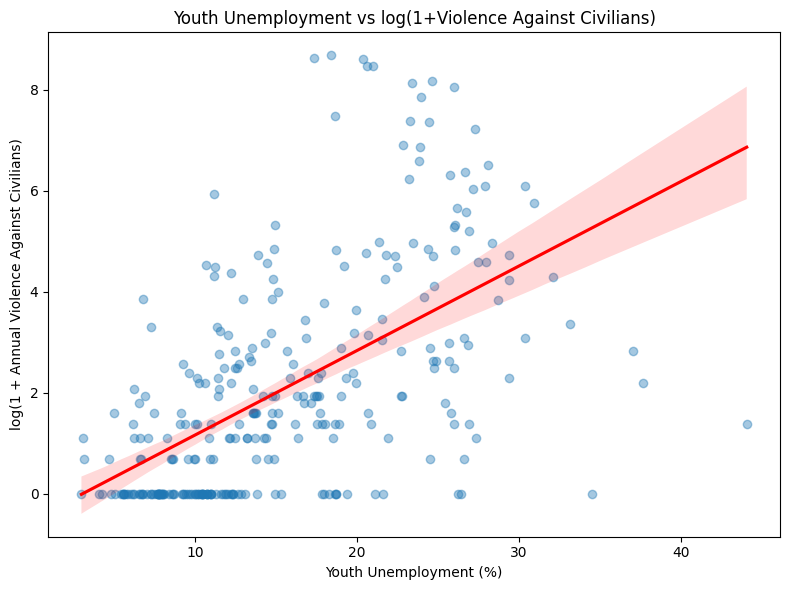

In [21]:
plt.figure(figsize=(8,6))
sns.regplot(
    data=agg,
    x="youth_unemployment",
    y=np.log1p(agg["Violence against civilians"]),
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

plt.title("Youth Unemployment vs log(1+Violence Against Civilians)")
plt.xlabel("Youth Unemployment (%)")
plt.ylabel("log(1 + Annual Violence Against Civilians)")
plt.tight_layout()
plt.show()

                   mean  median  count
youth_group                           
Low            2.725490     0.0    102
Medium        75.010000     5.0    100
High         494.852941    34.0    102


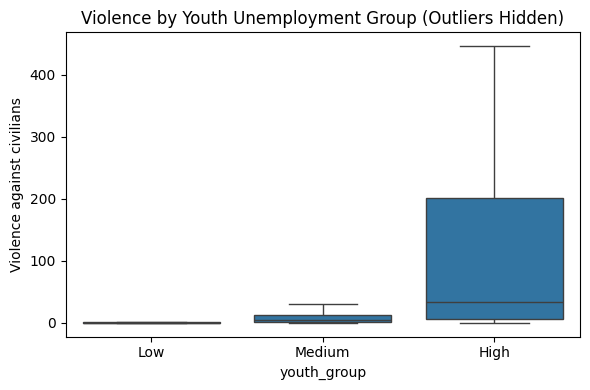

In [22]:
agg["youth_group"] = pd.qcut(
    agg["youth_unemployment"],
    q=3,
    labels=["Low","Medium","High"]
)

summary_youth = (
    agg.groupby("youth_group", observed=False)["Violence against civilians"]
    .agg(mean="mean", median="median", count="count")
)

print(summary_youth)

plt.figure(figsize=(6,4))
sns.boxplot(
    data=agg,
    x="youth_group",
    y="Violence against civilians",
    showfliers=False
)

plt.title("Violence by Youth Unemployment Group (Outliers Hidden)")
plt.tight_layout()
plt.show()

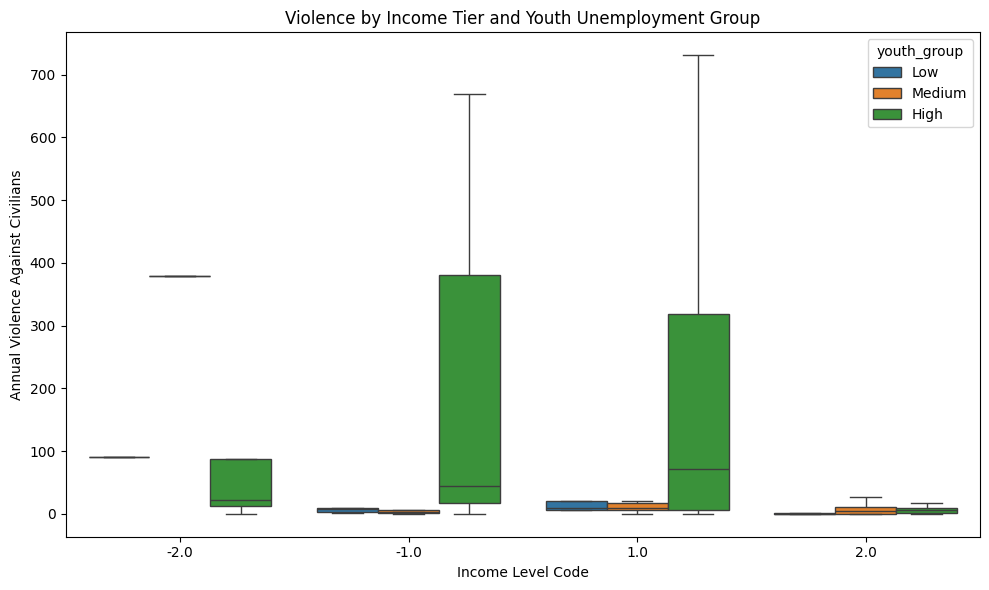

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=agg,
    x="income_level_code",
    y="Violence against civilians",
    hue="youth_group",
    showfliers=False
)

plt.title("Violence by Income Tier and Youth Unemployment Group")
plt.xlabel("Income Level Code")
plt.ylabel("Annual Violence Against Civilians")
plt.tight_layout()
plt.show()

**Findings: Youth Unemployment**

Youth unemployment exhibits a strong positive association with violence against civilians at the country-year level.

The relationship remains clearly positive after log transformation and displays threshold-like behavior: countries in the highest unemployment tertile experience disproportionately higher violence levels.

Within income tiers, the effect is strongest in low and very low income countries, suggesting that youth unemployment operates as a grievance multiplier in economically vulnerable contexts.

Youth unemployment thus appears to function as a semi-structural driver of instability, positioned between slow-moving inequality and short-term inflation shocks.

**Income level : just a quick check to be sure it's monotone**

In [24]:
income_summary = (
    agg.groupby("income_level_code", observed=False)["Violence against civilians"]
    .agg(mean="mean", median="median", count="count")
)

print(income_summary)

                         mean  median  count
income_level_code                           
-2.0               129.500000    59.5      6
-1.0               130.413793    20.0     29
 1.0               547.979167    20.0     96
 2.0                 6.294798     0.0    173


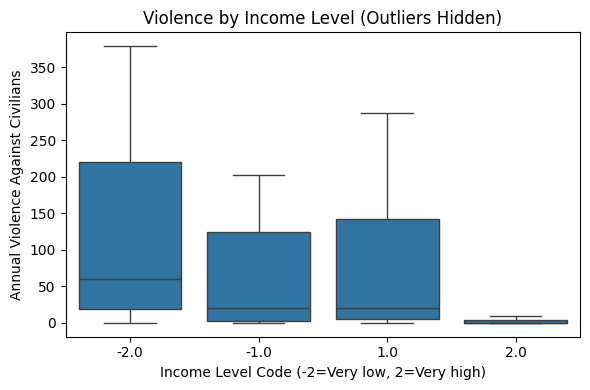

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=agg,
    x="income_level_code",
    y="Violence against civilians",
    showfliers=False
)

plt.title("Violence by Income Level (Outliers Hidden)")
plt.xlabel("Income Level Code (-2=Very low, 2=Very high)")
plt.ylabel("Annual Violence Against Civilians")
plt.tight_layout()
plt.show()

**inequality x inflation**

In [26]:
interaction_summary = (
    agg.groupby(["ineq_group", "inflation_shock"], observed=False)
    ["Violence against civilians"]
    .mean()
    .unstack()
)

print(interaction_summary)

inflation_shock           0           1
ineq_group                             
Low               13.872093    5.000000
Medium            19.024096   46.176471
High             487.310811  662.714286


In [47]:
interaction_battles = (
    agg.groupby(["ineq_group", "inflation_shock"], observed=False)["Battles"]
       .mean()
       .unstack()
)

print(interaction_battles)

inflation_shock           0           1
ineq_group                             
Low               36.081395    7.875000
Medium            26.662651   20.823529
High             376.135135  486.250000


In [46]:
interaction_remote = (
    agg.groupby(["ineq_group", "inflation_shock"], observed=False)
       ["Explosions/Remote violence"]
       .mean()
       .unstack()
)

print(interaction_remote)

inflation_shock          0          1
ineq_group                           
Low               8.686047   1.000000
Medium            6.493976  26.176471
High             34.310811  54.464286


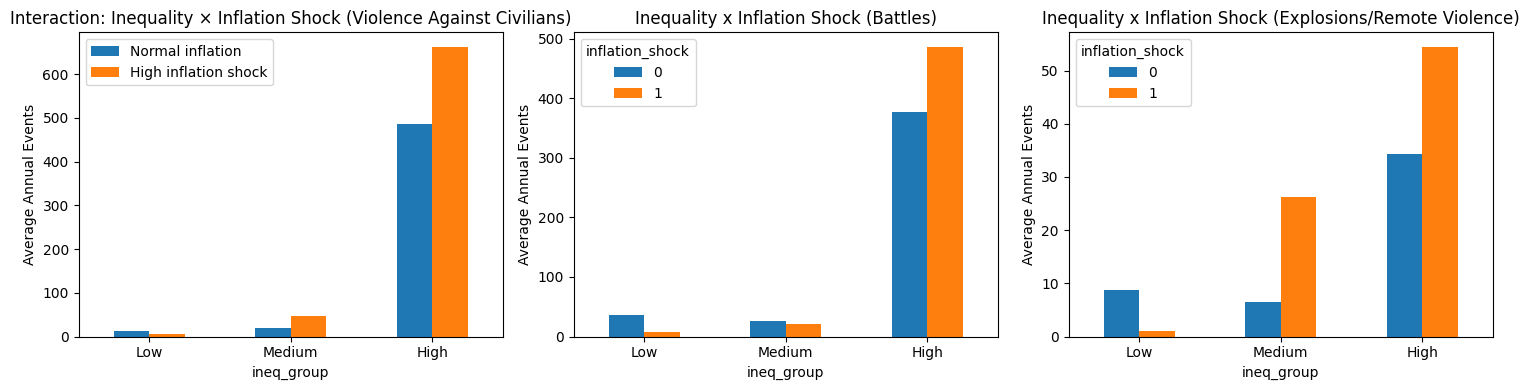

In [50]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

interaction_summary.plot(kind="bar", ax=axes[0])
axes[0].set_title("Interaction: Inequality × Inflation Shock (Violence Against Civilians)")
axes[0].legend(["Normal inflation", "High inflation shock"])

interaction_battles.plot(kind="bar", ax=axes[1])
axes[1].set_title("Inequality x Inflation Shock (Battles)")

interaction_remote.plot(kind="bar", ax=axes[2])
axes[2].set_title("Inequality x Inflation Shock (Explosions/Remote Violence)")

for ax in axes:
    ax.set_xlabel("ineq_group")
    ax.set_ylabel("Average Annual Events")
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Findings : Income Level**

Income level does not exhibit a smooth monotonic relationship with violence. While very high income countries show near-zero median violence and compressed distributions, other income tiers display overlapping patterns.

This suggests that income level primarily functions as a state capacity threshold: very high income countries appear structurally protected from large-scale violence, whereas lower income categories remain broadly vulnerable.

Income level thus operates more as a control variable than as a direct structural driver of conflict intensity.

Interaction analysis suggests that ***inflation shocks amplify violence primarily in structurally unequal countries.***
Low-inequality countries show resilience, while high-inequality systems exhibit substantial increases in violence during high inflation periods.
This supports fragility × economic trigger.

**inequality x youth unemployment**

In [32]:
interaction_youth = (
    agg.groupby(["ineq_group","youth_group"], observed=False)["Violence against civilians"].mean().unstack())

print(interaction_youth)

youth_group        Low      Medium        High
ineq_group                                    
Low           1.741379    4.666667   61.529412
Medium        1.457143   19.138889   56.000000
High         14.000000  180.702703  853.660714


In [35]:
interaction_youth_battles = (
    agg.groupby(["ineq_group","youth_group"], observed=False)["Battles"].mean().unstack())

print(interaction_youth_battles)

youth_group       Low     Medium        High
ineq_group                                  
Low          0.155172   0.518519  188.588235
Medium       0.057143   8.138889   78.344828
High         4.333333  36.459459  715.375000


In [38]:
interaction_youth_remote = (
    agg.groupby(["ineq_group","youth_group"], observed=False)["Explosions/Remote violence"].mean().unstack())

print(interaction_youth_remote)

youth_group       Low     Medium       High
ineq_group                                 
Low          0.155172   1.037037  42.705882
Medium       0.200000  12.166667  18.586207
High         0.111111  23.000000  57.357143


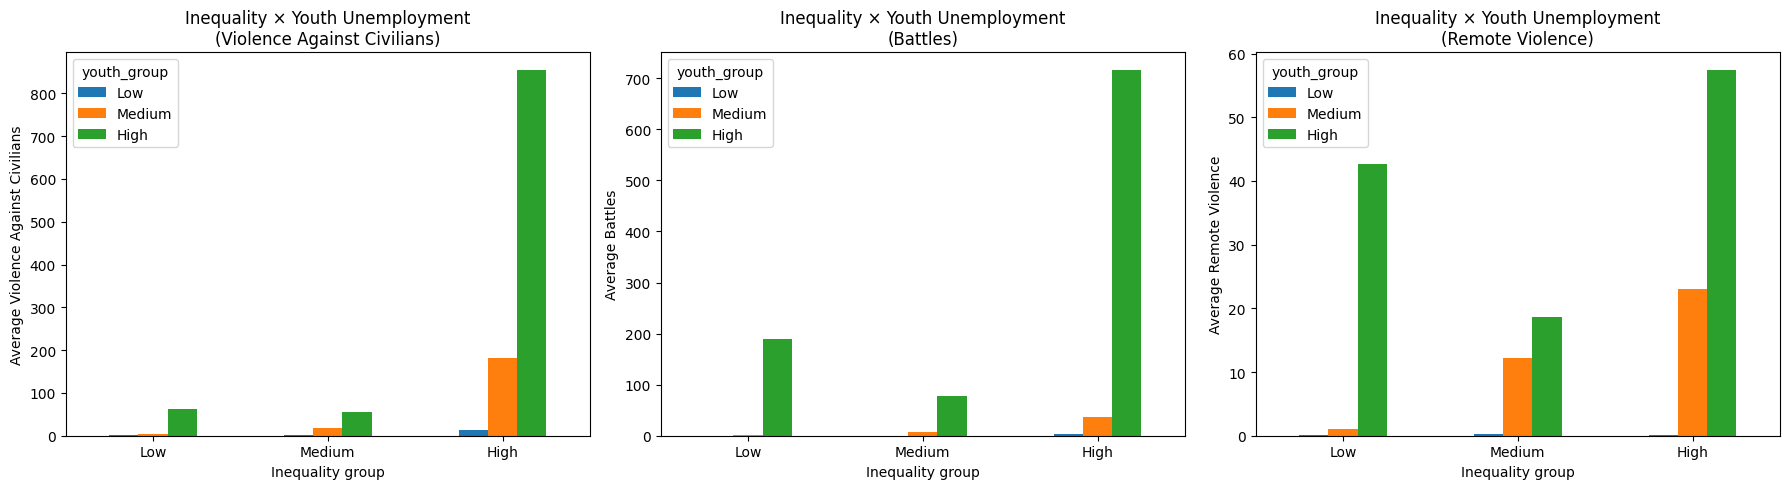

In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

interaction_youth.plot(kind="bar", ax=axes[0])
axes[0].set_title("Inequality × Youth Unemployment\n(Violence Against Civilians)")
axes[0].set_ylabel("Average Violence Against Civilians")

interaction_youth_battles.plot(kind="bar", ax=axes[1])
axes[1].set_title("Inequality × Youth Unemployment\n(Battles)")
axes[1].set_ylabel("Average Battles")

interaction_youth_remote.plot(kind="bar", ax=axes[2])
axes[2].set_title("Inequality × Youth Unemployment\n(Remote Violence)")
axes[2].set_ylabel("Average Remote Violence")

for ax in axes:
    ax.set_xlabel("Inequality group")
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Findings : Inequality × Youth Unemployment**

The interaction between income inequality and youth unemployment shows a strong relationship with conflict intensity. However, the matrix indicates that youth unemployment has a stronger direct effect than inequality alone.

When youth unemployment is low, levels of violence remain relatively low even in highly unequal societies. In contrast, when youth unemployment is high, conflict levels increase sharply across all inequality groups.

This suggests that ***youth unemployment acts as the primary driver of mobilization, while inequality amplifies the scale of conflict once mobilization capacity exists.*** In other words, inequality may create structural tension, but large populations of unemployed young people appear to be the key mechanism through which this tension translates into organized violence.

**exploring inflation x income level**

In [40]:
infl_inc_civilians = (
    agg.groupby(["income_level_code","inflation_shock"], observed=False)
       ["Violence against civilians"]
       .mean()
       .unstack()
)

print(infl_inc_civilians)

inflation_shock             0           1
income_level_code                        
-2.0                92.500000  203.500000
-1.0               145.434783   72.833333
 1.0               482.845070  732.960000
 2.0                 5.765517    9.035714


In [41]:
infl_inc_battles = (
    agg.groupby(["income_level_code","inflation_shock"], observed=False)
       ["Battles"]
       .mean()
       .unstack()
)

print(infl_inc_battles)

inflation_shock             0           1
income_level_code                        
-2.0                63.250000   28.000000
-1.0                70.565217   32.333333
 1.0               438.830986  551.800000
 2.0                 0.806897    1.785714


In [42]:
infl_inc_remote = (
    agg.groupby(["income_level_code","inflation_shock"], observed=False)
       ["Explosions/Remote violence"]
       .mean()
       .unstack()
)

print(infl_inc_remote)

inflation_shock            0          1
income_level_code                      
-2.0               31.000000   8.500000
-1.0               25.130435  52.500000
 1.0               32.690141  64.400000
 2.0                5.531034   1.571429


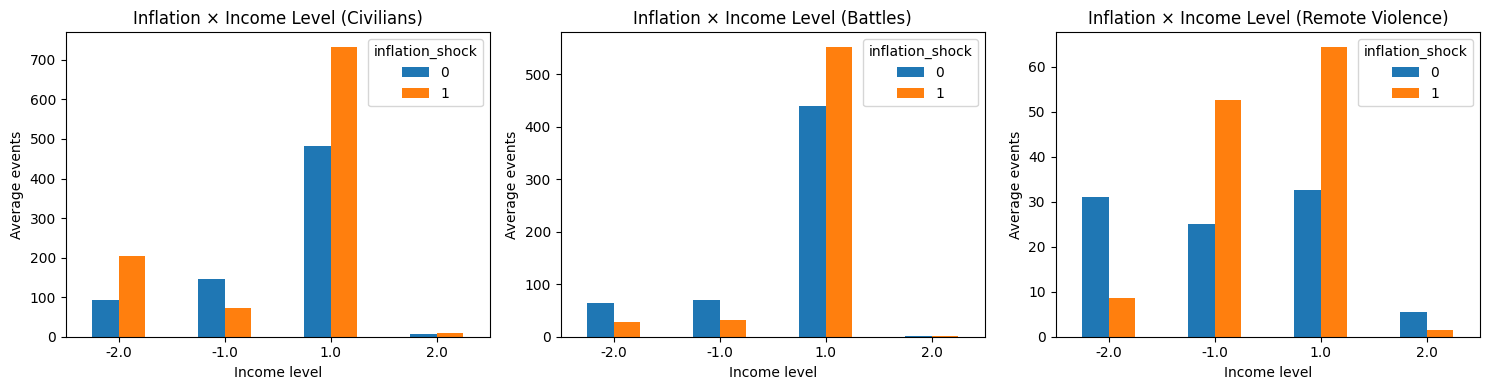

In [43]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

infl_inc_civilians.plot(kind="bar", ax=axes[0])
axes[0].set_title("Inflation × Income Level (Civilians)")

infl_inc_battles.plot(kind="bar", ax=axes[1])
axes[1].set_title("Inflation × Income Level (Battles)")

infl_inc_remote.plot(kind="bar", ax=axes[2])
axes[2].set_title("Inflation × Income Level (Remote Violence)")

for ax in axes:
    ax.set_xlabel("Income level")
    ax.set_ylabel("Average events")
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Findings: Income Level × Inflation Shock**

Inflation shocks appear to increase violence primarily in **middle income** countries.
**Very poor societies may face survival constraints that limit collective mobilization**, 
while high-income countries possess institutional capacity that absorbs economic shocks.

Middle-income states therefore represent a **transitional zone where economic shocks 
translate more easily into political instability** and conflict escalation.

This pattern is consistent with the broader findings in the dataset, where structural
vulnerability (inequality and youth unemployment) interacts with economic shocks
to increase the likelihood of conflict escalation.

**Correlation between Macro Variables**

In [53]:
import pandas as pd
macro_cols = [
    "inflation",
    "youth_unemployment",
    "income_inequality",
    "income_level_code"
]

macro_corr = agg[macro_cols].corr()

pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)
print(macro_corr)

                    inflation  youth_unemployment  income_inequality  income_level_code
inflation            1.000000            0.205930           0.146390          -0.167022
youth_unemployment   0.205930            1.000000           0.460692          -0.552219
income_inequality    0.146390            0.460692           1.000000          -0.231537
income_level_code   -0.167022           -0.552219          -0.231537           1.000000


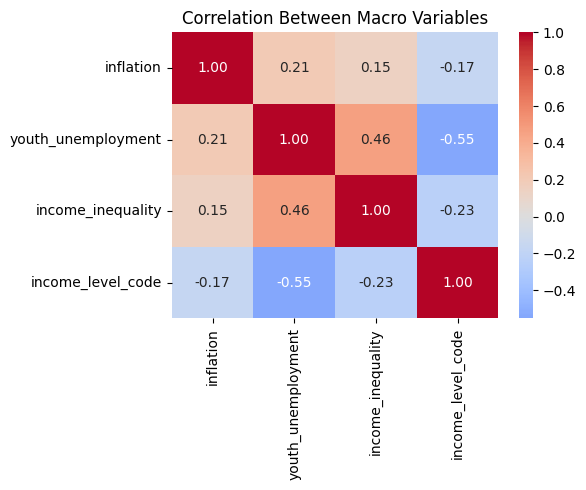

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    macro_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Between Macro Variables")
plt.tight_layout()
plt.show()

**Finding: Correlation Between Macro Variables**

The correlation matrix shows that the macroeconomic indicators capture
different dimensions of socioeconomic conditions and do not exhibit
extreme correlations.

The strongest relationship appears between **youth unemployment and
income inequality (0.46)**, indicating that societies with higher
inequality often also experience higher youth unemployment. (moderate correlation which is not problematic)

Income level shows a **strong negative relationship with youth
unemployment (-0.55)**, suggesting that poorer countries tend to have
higher youth unemployment rates.

Inflation appears relatively weakly correlated with the other macro
variables, implying that it behaves more as an independent economic
shock rather than a structural socioeconomic condition.

Overall, the moderate correlations suggest that the variables provide
complementary information and can reasonably be used together in the
predictive model.

**Distribution of macro variables**

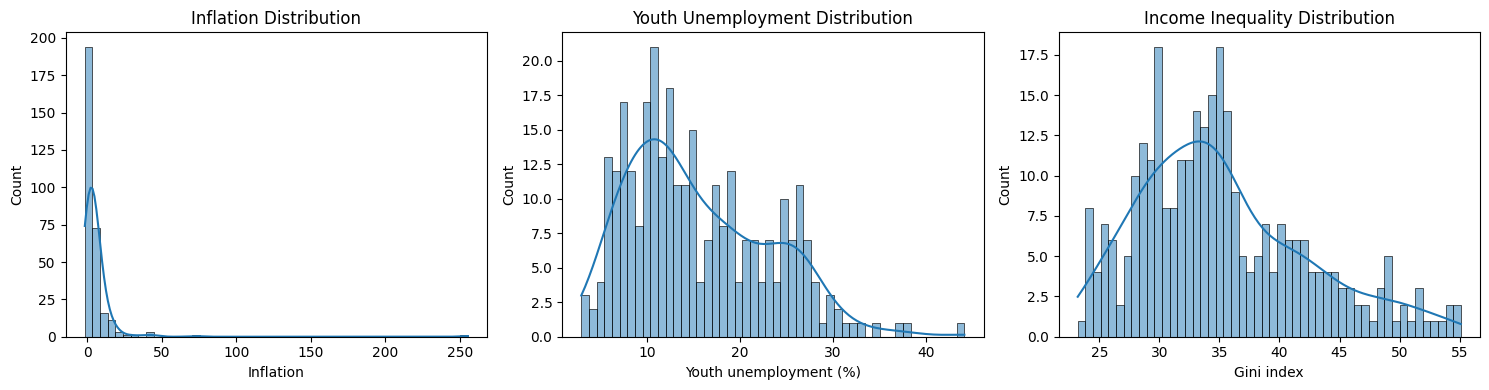

In [57]:
#just double check our findings
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# Inflation
sns.histplot(agg["inflation"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Inflation Distribution")
axes[0].set_xlabel("Inflation")

# Youth unemployment
sns.histplot(agg["youth_unemployment"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Youth Unemployment Distribution")
axes[1].set_xlabel("Youth unemployment (%)")

# Inequality
sns.histplot(agg["income_inequality"], bins=50, kde=True, ax=axes[2])
axes[2].set_title("Income Inequality Distribution")
axes[2].set_xlabel("Gini index")

#as income_level is not a continous variable we did not include it.

plt.tight_layout()
plt.show()

**Correlation between the target variables**

In [58]:
conflict_cols = [
    "Battles",
    "Explosions/Remote violence",
    "Violence against civilians"
]

conflict_corr = agg[conflict_cols].corr()
print(conflict_corr)

                             Battles  Explosions/Remote violence  Violence against civilians
Battles                     1.000000                    0.468325                    0.762285
Explosions/Remote violence  0.468325                    1.000000                    0.324110
Violence against civilians  0.762285                    0.324110                    1.000000


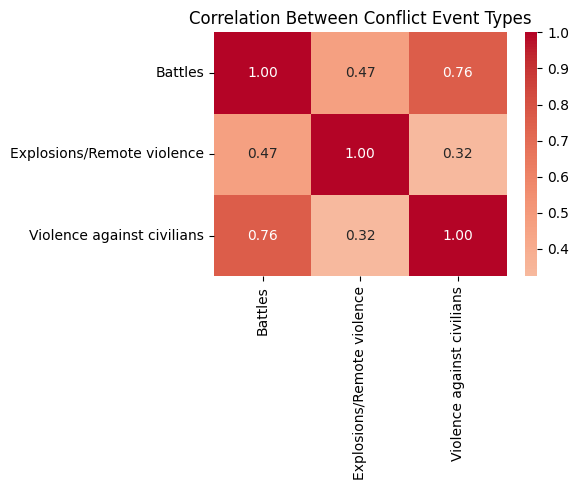

In [59]:
#just checking
plt.figure(figsize=(6,5))

sns.heatmap(
    conflict_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Between Conflict Event Types")

plt.tight_layout()
plt.show()

In [62]:
#just sanity check
country_conflict = (
    agg.groupby("country_code")[[
        "Battles",
        "Explosions/Remote violence",
        "Violence against civilians"
    ]]
    .mean()
    .sort_values("Battles", ascending=False).round(1)
)

country_conflict.head(20)

,Battles,Explosions/Remote violence,Violence against civilians
country_code,,,
BRA,4947.2,156.8,3725.0
MEX,1312.0,14.7,5666.0
ARM,944.8,66.8,5.2
COL,607.8,204.8,1307.4
CMR,531.0,68.0,506.0
TUR,341.2,186.0,114.8
PAK,314.0,195.0,315.0
IND,309.0,156.0,550.0
SLV,206.6,1.6,264.8


In [63]:
macro_risk = (
    agg.groupby(["ineq_group", "youth_group", "inflation_shock"], observed=False)
    ["Violence against civilians"]
    .mean()
    .reset_index()
)

print(macro_risk)

   ineq_group youth_group  inflation_shock  Violence against civilians
0         Low         Low                0                    1.940000
1         Low         Low                1                    0.500000
2         Low      Medium                0                    5.090909
3         Low      Medium                1                    2.800000
4         Low        High                0                   70.285714
5         Low        High                1                   20.666667
6      Medium         Low                0                    1.466667
7      Medium         Low                1                    1.400000
8      Medium      Medium                0                   14.333333
9      Medium      Medium                1                   43.166667
10     Medium        High                0                   48.043478
11     Medium        High                1                   86.500000
12       High         Low                0                   15.750000
13    

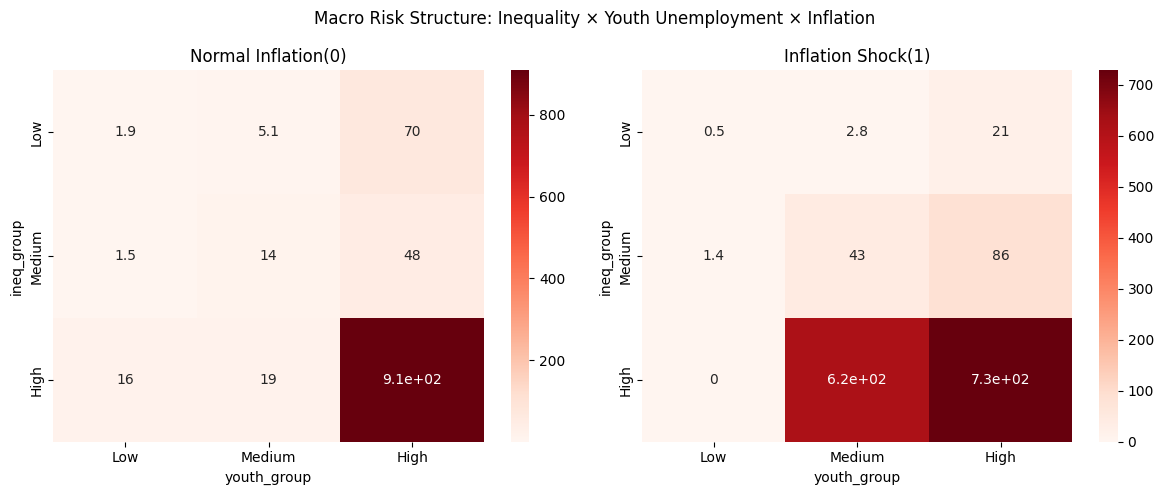

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    macro_risk[macro_risk["inflation_shock"]==0]
    .pivot(index="ineq_group", columns="youth_group", values="Violence against civilians"),
    annot=True,
    cmap="Reds",
    ax=axes[0]
)

axes[0].set_title("Normal Inflation(0)")

sns.heatmap(
    macro_risk[macro_risk["inflation_shock"]==1]
    .pivot(index="ineq_group", columns="youth_group", values="Violence against civilians"),
    annot=True,
    cmap="Reds",
    ax=axes[1]
)

axes[1].set_title("Inflation Shock(1)")

plt.suptitle("Macro Risk Structure: Inequality × Youth Unemployment × Inflation")

plt.tight_layout()
plt.show()

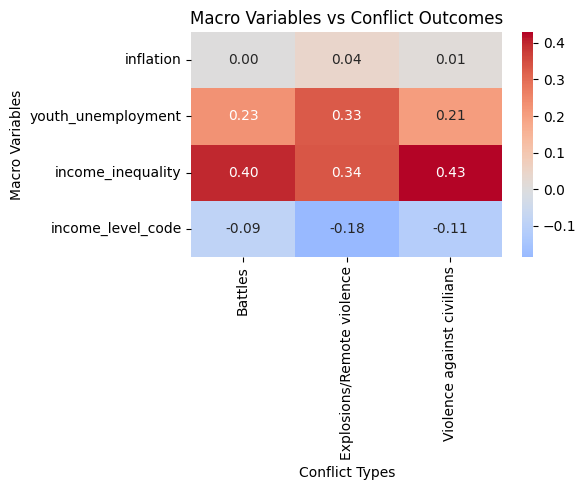

In [66]:
#final summary heat map
macro_cols = [
    "inflation",
    "youth_unemployment",
    "income_inequality",
    "income_level_code"
]

conflict_cols = [
    "Battles",
    "Explosions/Remote violence",
    "Violence against civilians"
]

summary_corr = agg[macro_cols + conflict_cols].corr()

summary_corr = summary_corr.loc[macro_cols, conflict_cols]

plt.figure(figsize=(6,5))

sns.heatmap(
    summary_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Macro Variables vs Conflict Outcomes")

plt.xlabel("Conflict Types")
plt.ylabel("Macro Variables")

plt.tight_layout()
plt.show()


**Final Structure** 
Structural pressure : income_inequality
mobilization capacity : youth_unemployment
shock trigger : inflation
Institutional buffer : income_level